<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/04_2_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)


--- Training the model to demonstrate Overfitting ---
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7613 - loss: 0.6491 - val_accuracy: 0.8462 - val_loss: 0.4133
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8605 - loss: 0.3790 - val_accuracy: 0.8649 - val_loss: 0.3737
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8761 - loss: 0.3375 - val_accuracy: 0.8786 - val_loss: 0.3354
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8856 - loss: 0.3088 - val_accuracy: 0.8784 - val_loss: 0.3447
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8923 - loss: 0.2893 - val_accuracy: 0.8809 - val_loss: 0.3380
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8963 - loss: 0.2808 - val_accuracy: 0.8763 - val_loss: 0.3477
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9006 - loss: 0.2674 - val_accuracy: 0.8857 - val_loss: 0.3105
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━

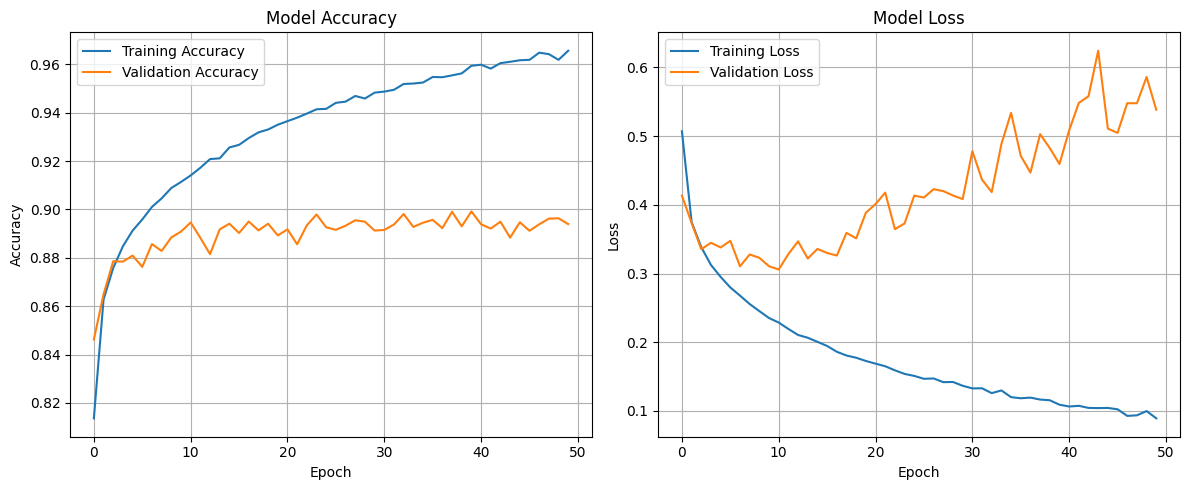

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Preprocess the Fashion MNIST Dataset
# Fashion MNIST is a dataset of Zalando's fashion article images.
# It's a good replacement for MNIST as it's slightly more challenging.
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to include a channel dimension (for CNNs, even though we use Dense here)
# For Dense layers, we'll flatten it later.
# For demonstration, we'll keep it simple and flatten directly.
train_images_flat = train_images.reshape((train_images.shape[0], 28 * 28))
test_images_flat = test_images.reshape((test_images.shape[0], 28 * 28))

# 2. Construct an Overfitting-Prone Model
# We'll create a relatively deep network with many neurons.
# This high capacity, combined with sufficient training epochs, will lead to overfitting.
model = keras.Sequential([
    layers.Input(shape=(28 * 28,)),  # Input layer for flattened images (784 pixels)
    layers.Dense(512, activation='relu'),  # Large hidden layer
    layers.Dense(256, activation='relu'),  # Another large hidden layer
    layers.Dense(128, activation='relu'),  # Even more layers
    layers.Dense(64, activation='relu'),   # Deeper still
    layers.Dense(10, activation='softmax')  # Output layer for 10 classes (0-9)
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary to see the number of parameters
model.summary()

# 4. Train the Model for Many Epochs (to induce overfitting)
# We use a validation_split to set aside some training data for validation.
# This allows us to monitor performance on unseen data during training.
print("\n--- Training the model to demonstrate Overfitting ---")
history = model.fit(train_images_flat, train_labels,
                    epochs=50,  # Train for a large number of epochs
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=1)

# 5. Evaluate the Model on the Test Set
test_loss, test_acc = model.evaluate(test_images_flat, test_labels, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

# 6. Visualize Training vs. Validation Performance
# This is crucial for observing overfitting
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Understanding Overfitting

As you can see in the plots, the 'Training Accuracy' continues to rise and 'Training Loss' continues to fall throughout the training process.
However, the 'Validation Accuracy' peaks early and then starts to decrease, while the 'Validation Loss' begins to increase after a certain point.
This divergence is the hallmark of overfitting: the model has started to memorize the training data, including its noise, and is no longer generalizing well to new, unseen validation data.



## Simple Techniques to Mitigate Overfitting

1. Early Stopping: Stop training the model when the performance on the validation set starts to worsen, instead of letting it run for a fixed number of epochs.
2. Simpler Model: Reduce the complexity of the model by using fewer layers or fewer neurons per layer. A less powerful model has less capacity to memorize the training data.
3. Dropout: Randomly 'turns off' a percentage of neurons during training, forcing the network to learn more robust features.
4. More Data/Data Augmentation: Providing more diverse training examples makes it harder for the model to simply memorize, encouraging it to learn broader patterns. Data augmentation creates artificial new data by transforming existing samples (e.g., rotating images).